# AAV2 — `Protocol` (classe mécaniste) sur les 50k variants org2 ∩ org3

Port direct de `AAV5/selectivity/analysis of recovery/AAV5_SEL_fitting_protocol_org2org3.ipynb` — même question : la classe `ProtocolV3` (simulation mécaniste plasmide -> virus -> organoïde), avec les poids de Potts déjà extraits et des **paramètres classiques** (pas de sweep), reproduit-elle des stats/distributions plausibles pour la **sélectivité**, sur les variants identifiés comme les plus fiables (intersection org2 ∩ org3) ?

## Différence avec le port AAV5

AAV5 partait d'un CSV org2∩org3 déjà construit (`AAV5_organoides_sorted_sel_org2org3.csv`, section 5 d'`AAV5_sel_sorting.ipynb`). Aucun équivalent n'existe encore pour AAV2 — la section 0 ci-dessous construit cette population **en ligne**, directement depuis le CSV brut `AAV2_organoides.csv`, avec `compte_plasmide ≥ 1` (exclut seulement les lignes non-finies) à la place du retrait 7m8 d'AAV5 (aucun spike-in trouvé côté AAV2), puis l'intersection stricte `compte_organoide_2_adn > 0 ET compte_organoide_3_adn > 0`.

**⚠ Correction (2026-09-16) : le cap `ratio_virus/plasmide ≤ 100` a été retiré.** Il était hérité de `AAV2_viab_sorting.ipynb`, mais un cap sur le RATIO équivaut par construction à tronquer tout `log2 enrichment` réel au-delà de `log2(100)=6.64` — vérifié sur les données : ça rayait 100% des variants à `y>6.64` et déjà 75% de ceux à `y>6`. Pas un filtre de bruit, une amputation de la queue haute (les variants les plus enrichis, précisément ceux qu'on cherche). Seul filtre qualité restant : `compte_plasmide ≥ 1`. Les sections 5/6 affichent maintenant les valeurs brutes (non recalées médiane) pour rendre ce genre d'artefact directement visible plutôt que masqué par un recentrage.

## Poids

- **Viabilité** : `aav2_F_viab_potts_sorted_cv.npy` / `aav2_J_viab_potts_sorted_cv.npy` — le fit Potts de `AAV2_viab_sorting.ipynb` sur `AAV2_organoides_sorted.csv` (même lignée organoïde/haute-diversité que les poids de sélectivité ci-dessous — même séquences, même CSV source). **PAS** `aav2_F_viab_potts_plasmid50_vectorpos_cv.npy` (la GT canonique par défaut décidée dans `AAV2_potts_regression.ipynb` §12c) : ces poids-là viennent d'un CSV totalement différent (`aav2.csv`, basse diversité, 53 382 séquences), et le mélanger avec les poids de sélectivité organoïde mélangerait deux lignées de données distinctes — cohérent avec la règle déjà posée ("HIGH DIVERSITY, à n'utiliser QUE pour comparer explicitement high-diversity vs low-diversity"). **Note** : ce fit `aav2_F_viab_potts_sorted_cv.npy` a lui-même été produit sur une population filtrée avec l'ancien cap `ratio≤100` (`AAV2_viab_sorting.ipynb`, jamais retouché) — donc potentiellement affecté par le même biais de troncature, pas encore corrigé à la source.
- **Sélectivité** : `aav2_F_sel_pool_potts_sorted_readoutT5_unreg.npy` / `aav2_J_sel_pool_potts_sorted_readoutT5_unreg.npy` — le fit mutualisé org2+org3 à `T_CHOSEN=5` d'`AAV2_SEL_potts_readout_depth.ipynb` (**décision utilisateur 2026-09-16** — cf. section 9 de ce notebook : `r(F2,F3)` bien plus élevé à T=5 qu'à T=20). Ce fit utilise aussi le filtre qualité-viab de base, donc également affecté par le retrait du cap ratio — à re-générer après la correction de `AAV2_SEL_potts_readout_depth.ipynb`.

## Paramètres « classiques »

Repris tels quels du point de fonctionnement d'`AAV5_SEL_fitting_protocol.ipynb` (`rho=1e-3`, `mu=50`, `T_viab=T_sel=1/ln(2)`, `noise_viab=noise_sel=0.5`, `D=1e8`, `dilution_factor=1e5`) — **aucun point de fonctionnement propre à AAV2 n'a encore été établi pour la simulation combinée viab+sélectivité** (contrairement à la viabilité seule, cf. `AAV2_viab_fitting_protocol.ipynb`/`AAV2_viab_top10k_potts_protocol_mlp.ipynb` qui ont leur propre `D`). Aucun sweep, aucune recherche ici — on regarde juste si les formes tiennent avec ce point de départ emprunté.

**Autre choix hérité, non remis en cause ici** : la winsorisation p99 de `plasmid_count` (section 1) — nécessaire numériquement (`produce_capsids()` explose en mémoire sans cap sur le variant le plus abondant), reprise telle quelle du port AAV5, pas re-dérivée pour AAV2.

Terminologie respectée : log enrichment, jamais « score » pour une prédiction/mesure.

### 0. Setup + population org2 ∩ org3 (construite en ligne, cf. différence ci-dessus)

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

from analysisV1 import AA_LABELS, pearson, precision_at_k, number_of_seq_threshold
from sequence_classesV1 import ProtocolV3, message as scv_msg
print("sequence_classesV1:", scv_msg, "| JAX:", jax.default_backend(), jax.devices())

CSV = Path("AAV2_organoides.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/AAVs dataset/AAV2/AAV2_organoides.csv"
assert CSV.exists(), CSV

L, A = 7, 20
EPS = 0.5  # convention projet -- toujours eps=0.5, jamais +1

viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_col  = {2: "log2_enrichissement_organoide_2_adn_sur_virus",
            3: "log2_enrichissement_organoide_3_adn_sur_virus"}
cnt_col  = {2: "compte_organoide_2_adn", 3: "compte_organoide_3_adn"}
use = ["sequence", "compte_plasmide", "compte_virus", viab_col, *sel_col.values(), *cnt_col.values()]
dtypes = {c: "float32" for c in use if c != "sequence"} | {"sequence": "string"}

df_raw = pd.read_csv(CSV, usecols=use, dtype=dtypes)
df_raw["sequence"] = df_raw["sequence"].astype("string")
print(f"CSV brut : {df_raw.shape[0]:,} lignes")

plasmid_raw = df_raw["compte_plasmide"].to_numpy(np.float64)
virus_raw   = df_raw["compte_virus"].to_numpy(np.float64)

# PAS de cap sur le ratio virus/plasmide -- retire sur demande explicite (2026-09-16). Un cap
# ratio<=R equivaut par construction a tronquer TOUT log2 enrichment reel au-dela de log2(R) : a
# R=100 ca revenait a rayer 100% des variants a y>6.64, et deja 75% de ceux a y>6 -- pas un filtre
# de bruit, une amputation de la queue haute (les variants les plus enrichis), verifie directement
# sur les donnees. Seul filtre restant : compte_plasmide >= PLASMID_MIN (exclut juste les lignes a
# plasmide nul, deja non-finies de toute facon).
PLASMID_MIN = 1
viab_keep   = (plasmid_raw >= PLASMID_MIN)

org2_raw = df_raw[cnt_col[2]].to_numpy(np.float64)
org3_raw = df_raw[cnt_col[3]].to_numpy(np.float64)
inter_keep = viab_keep & (org2_raw > 0) & (org3_raw > 0)

print(f"viab_keep (plasmid>={PLASMID_MIN}, pas de cap ratio)  : {int(viab_keep.sum()):,}")
print(f"org2 > 0                                     : {int((org2_raw > 0).sum()):,}")
print(f"org3 > 0                                     : {int((org3_raw > 0).sum()):,}")
print(f"org2 > 0 ET org3 > 0 (intersection)           : {int(((org2_raw > 0) & (org3_raw > 0)).sum()):,}")
print(f"population org2 ∩ org3 (+ viab_keep)         : {int(inter_keep.sum()):,}  "
      f"({inter_keep.mean():.2%} du brut)")

df_full = df_raw.loc[inter_keep].reset_index(drop=True)
print(f"CSV org2∩org3 (construit en ligne) : {df_full.shape[0]:,} lignes")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sequence_classesV1: file 2.1 | JAX: gpu [CudaDevice(id=0)]
CSV brut : 4,273,463 lignes
viab_keep (plasmid>=1, pas de cap ratio)  : 2,810,598
org2 > 0                                     : 131,845
org3 > 0                                     : 183,342
org2 > 0 ET org3 > 0 (intersection)           : 72,671
population org2 ∩ org3 (+ viab_keep)         : 47,563  (1.11% du brut)
CSV org2∩org3 (construit en ligne) : 47,563 lignes


### 1. Sous-échantillon de 50 000 variants + librairie initiale = avg(org2, org3)

In [2]:
N_SIM = 50_000
rng = np.random.default_rng(0)
sim_idx = rng.choice(len(df_full), size=min(N_SIM, len(df_full)), replace=False)
df = df_full.iloc[sim_idx].reset_index(drop=True)
print(f"sous-echantillon : {len(df):,} variants")

lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)
sequences = jnp.asarray(seq_matrix)
d0 = len(df)

y_viab = df[viab_col].to_numpy(np.float64)
y_sel  = {i: df[sel_col[i]].to_numpy(np.float64) for i in (2, 3)}
c2 = df[cnt_col[2]].to_numpy(np.float64)
c3 = df[cnt_col[3]].to_numpy(np.float64)
assert (c2 > 0).all() and (c3 > 0).all(), "la population org2∩org3 doit garantir org2>0 ET org3>0 partout"
assert np.isfinite(y_sel[2]).all() and np.isfinite(y_sel[3]).all()

plasmid_count_raw = (c2 + c3) / 2.0  # -- la "librairie initiale" demandee
print("plasmid_count = avg(compte_organoide_2_adn, compte_organoide_3_adn) -- percentiles "
      "[0,10,25,50,75,90,99,99.9,100]:")
print(np.round(np.percentile(plasmid_count_raw, [0, 10, 25, 50, 75, 90, 99, 99.9, 100]), 2))
print(f"viab reel fini : {np.isfinite(y_viab).mean():.1%}  (n={np.isfinite(y_viab).sum():,})")

# Winsorisation au p99 -- meme raison numerique que le port AAV5 (produce_capsids() materialise
# un tableau (d0, max_cells) ; un variant extreme fait exploser max_cells et peut faire planter
# le GPU par OOM sans cap).
PLASMID_CAP_PCTL = 99
plasmid_cap = np.percentile(plasmid_count_raw, PLASMID_CAP_PCTL)
n_capped = int((plasmid_count_raw > plasmid_cap).sum())
plasmid_count = np.minimum(plasmid_count_raw, plasmid_cap)
print(f"winsorisation p{PLASMID_CAP_PCTL} = {plasmid_cap:.1f}  ({n_capped:,} lignes cappees, "
      f"{n_capped / d0:.2%})")

sous-echantillon : 47,563 variants
plasmid_count = avg(compte_organoide_2_adn, compte_organoide_3_adn) -- percentiles [0,10,25,50,75,90,99,99.9,100]:
[5.000000e-01 1.025000e+01 7.350000e+01 1.580000e+02 3.440000e+02
 8.206500e+02 6.624800e+03 4.027776e+04 2.314315e+05]
viab reel fini : 100.0%  (n=47,563)
winsorisation p99 = 6624.8  (476 lignes cappees, 1.00%)


### 2. Poids Potts (déjà extraits -- pas de nouveau fit ici)

In [3]:
F_VIAB_PATH = LIB / "aav2_F_viab_potts_sorted_cv.npy"
J_VIAB_PATH = LIB / "aav2_J_viab_potts_sorted_cv.npy"
F_SEL_PATH  = LIB / "aav2_F_sel_pool_potts_sorted_readoutT5_unreg.npy"
J_SEL_PATH  = LIB / "aav2_J_sel_pool_potts_sorted_readoutT5_unreg.npy"
for p in (F_VIAB_PATH, J_VIAB_PATH, F_SEL_PATH, J_SEL_PATH):
    assert p.exists(), (f"{p.name} introuvable -- lancer AAV2_viab_sorting.ipynb (viab) et/ou "
                        f"la section 6 d'AAV2_SEL_potts_readout_depth.ipynb a T_CHOSEN=5 (sel) d'abord")

F_viab = np.load(F_VIAB_PATH)
J_viab = np.load(J_VIAB_PATH)
F_sel  = np.load(F_SEL_PATH)
J_sel  = np.load(J_SEL_PATH)
print("F_viab", F_viab.shape, "J_viab", J_viab.shape, "| F_sel", F_sel.shape, "J_sel", J_sel.shape)


def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(L)].sum(axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s

F_viab (20, 7) J_viab (7, 7, 20, 20) | F_sel (20, 7) J_sel (7, 7, 20, 20)


### 3. Score GT déterministe vs réel (plafond, avant toute simulation)

`compute_score(F, J)` = `F + J` sans bruit de protocole -- le plafond de ce que la simulation peut espérer.

In [4]:
viab_score_GT = score_FJ(seq_matrix, F_viab, J_viab)
sel_score_GT  = score_FJ(seq_matrix, F_sel,  J_sel)

r_viab_gt = pearson(y_viab[np.isfinite(y_viab)], viab_score_GT[np.isfinite(y_viab)])
r_sel_gt  = {i: pearson(y_sel[i], sel_score_GT) for i in (2, 3)}
print(f"r(score GT viab, reel viab)   = {r_viab_gt:+.3f}   (n={np.isfinite(y_viab).sum():,})")
for i in (2, 3):
    print(f"r(score GT sel, reel org{i})  = {r_sel_gt[i]:+.3f}   (n={d0:,})")

r(score GT viab, reel viab)   = +0.278   (n=47,563)
r(score GT sel, reel org2)  = +0.460   (n=47,563)
r(score GT sel, reel org3)  = +0.559   (n=47,563)


### 4. Configuration `ProtocolV3` -- paramètres classiques, `lambda0` = librairie réelle

Le constructeur initialise `lambda0` UNIFORME (`N0/d0`) -- on l'écrase juste après par un `lambda0` calibré pour que *après* le `dilution_factor` (l'étape `sample_sequences()`, Binomial(pool, p=1/dilution_factor)) on retombe en espérance sur `plasmid_count` = `avg(org2, org3)` (cf. cellule suivante).

In [5]:
RHO        = 1e-3
MU         = 50
T_VIAB     = 1.0 / np.log(2)
T_SEL      = 1.0 / np.log(2)
NOISE_VIAB = 0.5
NOISE_SEL  = 0.5
D          = 1e8
DILUTION   = 1e5

N1 = MU * d0 / RHO

# On veut E[sample_sequences()] = plasmid_count APRES dilution -- lambda0 = plasmid_count * DILUTION
# fait retomber cette moyenne exactement sur plasmid_count(s) pour chaque sequence (meme raison
# que le port AAV5). Les PROPORTIONS de lambda0 (ce qui pilote produce_capsids()) sont inchangees
# par ce facteur global -- la winsorisation p99 ci-dessus reste valable telle quelle.
lambda0_init = plasmid_count * DILUTION
N0 = float(lambda0_init.sum())  # documentation seulement (N_loop_DE() n'est pas utilise ici)

print(f"mu={MU}  T_viab=T_sel={T_VIAB:.3f}  noise={NOISE_VIAB}/{NOISE_SEL}  D={D:.0e}  "
      f"N1={N1:.2e}  N0={N0:.2e}  D/d0={D/d0:.0f} reads/variant")
print(f"E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur plasmid_count : "
      f"median lambda0/DILUTION={np.median(lambda0_init) / DILUTION:.1f} vs median plasmid_count="
      f"{np.median(plasmid_count):.1f}")


def simulate_round(seed):
    p = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0, N1=N1, dilution_factor=DILUTION,
                   sequences=sequences, D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
                   noise_viab=NOISE_VIAB, noise_sel=NOISE_SEL, T_viab=T_VIAB, T_sel=T_SEL,
                   multinomialNGS=True, rho=RHO)
    p.lambda0 = jnp.asarray(lambda0_init)  # <-- calibre pour retomber sur avg(org2,org3) apres dilution
    bio, ngs = p.loop_DE()
    l0p, l2p, l3p = (np.asarray(a, np.float64) for a in ngs)
    sim_viab = np.log2((l2p + EPS) / (l0p + EPS))
    sim_sel  = np.log2((l3p + EPS) / (l2p + EPS))
    return dict(p=p, l0p=l0p, l2p=l2p, l3p=l3p, sim_viab=sim_viab, sim_sel=sim_sel)


sims = [simulate_round(s) for s in (0, 1, 2)]
for k, s in enumerate(sims):
    print(f"  rep{k}: sim_viab fini {np.isfinite(s['sim_viab']).mean():.2%}  "
          f"sim_sel fini {np.isfinite(s['sim_sel']).mean():.2%}  (l3p>0 : {(s['l3p'] > 0).mean():.2%})")

mu=50  T_viab=T_sel=1.443  noise=0.5/0.5  D=1e+08  N1=2.38e+09  N0=1.95e+12  D/d0=2102 reads/variant
E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur plasmid_count : median lambda0/DILUTION=158.0 vs median plasmid_count=158.0


  rep0: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 51.55%)
  rep1: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 51.48%)
  rep2: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 51.50%)


### 5. Viabilité -- réel vs simulé

`log2_enrichissement_virus_sur_plasmide` réel vs `log2((lambda2p+eps)/(lambda0p+eps))` simulé. **Valeurs brutes, non recalées** (sur demande explicite 2026-09-16 -- le recentrage médiane précédent n'affectait pas `r`, mais déplaçait la valeur affichée du mur causé par l'ancien cap `ratio≤100`, rendant le diagnostic plus difficile).

r(sim_viab, reel viab) = +0.237   (n=47,563, GT score r=+0.278)


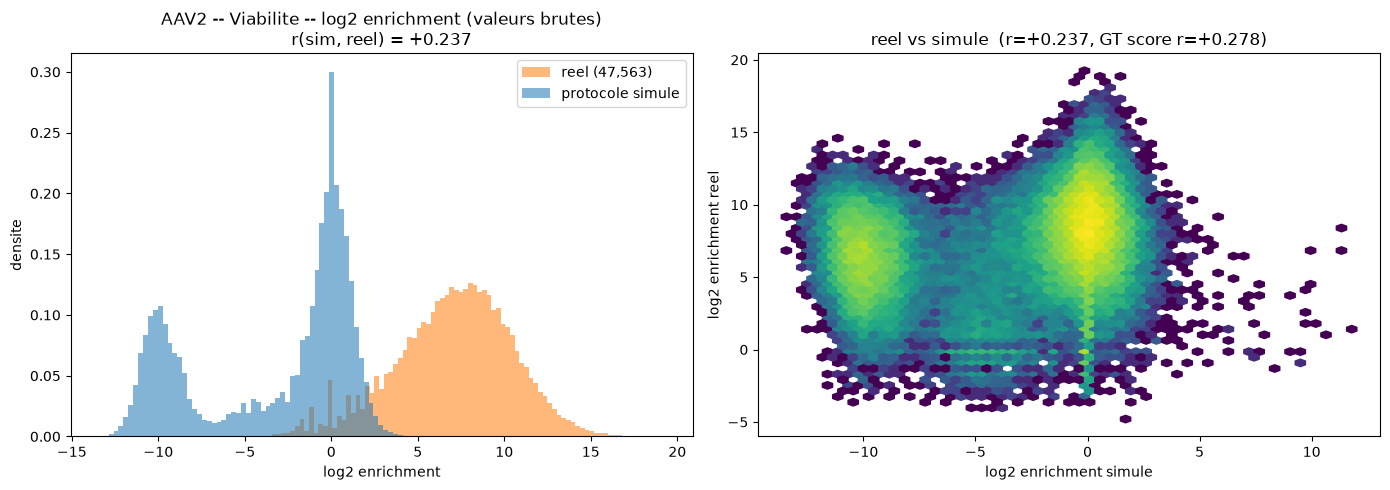

In [6]:
sim_viab = sims[0]["sim_viab"]
mfin = np.isfinite(y_viab) & np.isfinite(sim_viab)
r_viab_sim = pearson(y_viab[mfin], sim_viab[mfin])
print(f"r(sim_viab, reel viab) = {r_viab_sim:+.3f}   (n={mfin.sum():,}, GT score r={r_viab_gt:+.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lo, hi = y_viab[mfin].min(), y_viab[mfin].max()
lo_s, hi_s = sim_viab[mfin].min(), sim_viab[mfin].max()
bins_real = np.linspace(lo, hi, 90)
bins_sim  = np.linspace(lo_s, hi_s, 90)
axes[0].hist(y_viab[mfin], bins=bins_real, density=True, alpha=0.55, color="tab:orange", label=f"reel ({mfin.sum():,})")
axes[0].hist(sim_viab[mfin], bins=bins_sim, density=True, alpha=0.55, color="tab:blue",   label="protocole simule")
axes[0].set(title=f"AAV2 -- Viabilite -- log2 enrichment (valeurs brutes)\nr(sim, reel) = {r_viab_sim:+.3f}",
            xlabel="log2 enrichment", ylabel="densite"); axes[0].legend()

axes[1].hexbin(sim_viab[mfin], y_viab[mfin], gridsize=55, bins="log", cmap="viridis", mincnt=1)
axes[1].set(title=f"reel vs simule  (r={r_viab_sim:+.3f}, GT score r={r_viab_gt:+.3f})",
            xlabel="log2 enrichment simule", ylabel="log2 enrichment reel")
plt.tight_layout(); plt.show()

### 6. Sélectivité -- réel (org2, org3) vs protocole (3 réplicats simulés)

`log2_enrichissement_organoide_{2,3}_adn_sur_virus` réel vs `log2((lambda3p+eps)/(lambda2p+eps))` simulé (3 réplicats, clés différentes). **Valeurs brutes, non recalées** (même raison que la section 5).

r(sim_sel rep0, reel org2) = +0.210   (n=47,563, GT score r=+0.460)
r(sim_sel rep0, reel org3) = +0.266   (n=47,563, GT score r=+0.559)


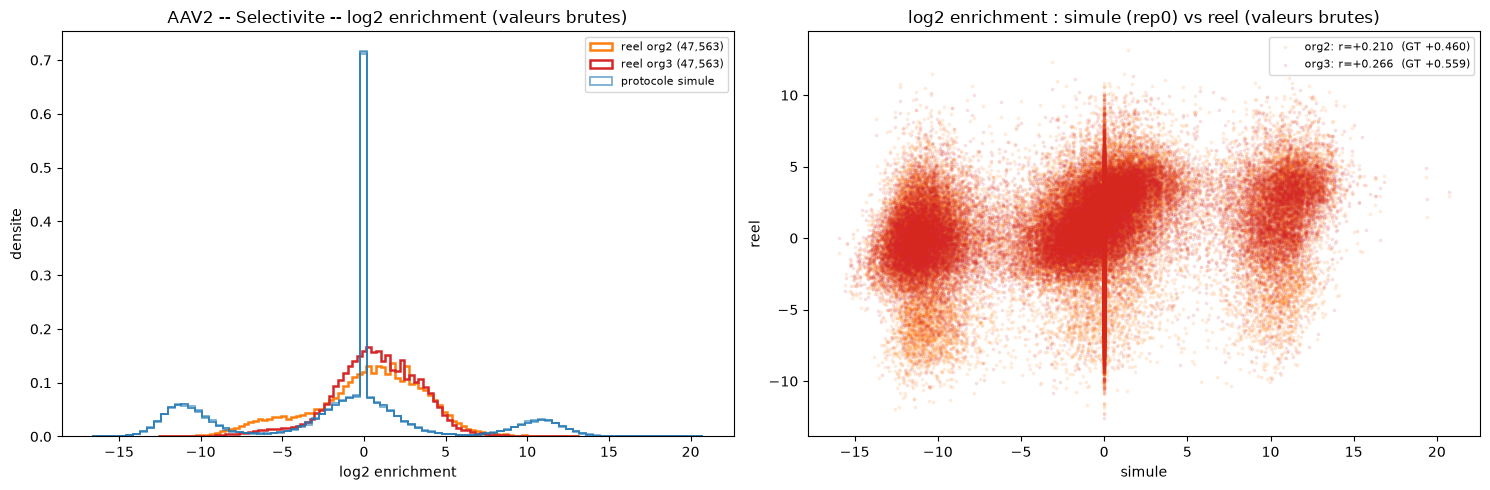

accord replicat-replicat :
  reel   org2 vs org3  : +0.491
  simule rep0 vs rep1  : +0.284
  simule rep0 vs rep2  : +0.293


In [7]:
sims_sel_raw = [s["sim_sel"] for s in sims]
real_sel_raw = {i: y_sel[i] for i in (2, 3)}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins_real = np.linspace(min(real_sel_raw[2].min(), real_sel_raw[3].min()),
                         max(real_sel_raw[2].max(), real_sel_raw[3].max()), 90)
axes[0].hist(real_sel_raw[2], bins=bins_real, density=True, histtype="step", lw=1.8,
             color="tab:orange", label=f"reel org2 ({d0:,})")
axes[0].hist(real_sel_raw[3], bins=bins_real, density=True, histtype="step", lw=1.8,
             color="tab:red", label=f"reel org3 ({d0:,})")

sim_finite_all = np.concatenate([ss[np.isfinite(ss)] for ss in sims_sel_raw])
bins_sim = np.linspace(sim_finite_all.min(), sim_finite_all.max(), 90)
for k, ss in enumerate(sims_sel_raw):
    axes[0].hist(ss[np.isfinite(ss)], bins=bins_sim, density=True, histtype="step", lw=1.3,
                 color="tab:blue", alpha=0.6, label="protocole simule" if k == 0 else None)
axes[0].set(title="AAV2 -- Selectivite -- log2 enrichment (valeurs brutes)",
            xlabel="log2 enrichment", ylabel="densite"); axes[0].legend(fontsize=8)

s0 = sims_sel_raw[0]
for i, col in zip((2, 3), ("tab:orange", "tab:red")):
    m = np.isfinite(s0)
    r = pearson(real_sel_raw[i][m], s0[m])
    print(f"r(sim_sel rep0, reel org{i}) = {r:+.3f}   (n={m.sum():,}, GT score r={r_sel_gt[i]:+.3f})")
    axes[1].scatter(s0[m], real_sel_raw[i][m], s=3, alpha=0.1, color=col,
                    label=f"org{i}: r={r:+.3f}  (GT {r_sel_gt[i]:+.3f})")
axes[1].set(title="log2 enrichment : simule (rep0) vs reel (valeurs brutes)", xlabel="simule", ylabel="reel")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

def r_between(a, b):
    a, b = np.asarray(a), np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    return pearson(a[m], b[m])

print("accord replicat-replicat :")
print(f"  reel   org2 vs org3  : {r_between(real_sel_raw[2], real_sel_raw[3]):+.3f}")
print(f"  simule rep0 vs rep1  : {r_between(sims_sel_raw[0], sims_sel_raw[1]):+.3f}")
print(f"  simule rep0 vs rep2  : {r_between(sims_sel_raw[0], sims_sel_raw[2]):+.3f}")

### 6b. Sélectivité — comparaison avec le fit "accord proportionnel" org2≈org3

`AAV2_SEL_potts_readout_depth.ipynb` filtre par seuil ABSOLU (`compte ≥ T`), ce qui élimine systématiquement les variants peu abondants — y compris les "mauvais" (peu ou pas sélectionnés), pas seulement les bruités. `AAV2_SEL_potts_proportional_agreement.ipynb` (nouveau notebook, sur demande explicite) fitte à la place sur les variants où `|compte_organoide_2 - compte_organoide_3| ≤ (compte_organoide_2 + compte_organoide_3)/5` — un accord RELATIF entre réplicats plutôt qu'un plancher d'abondance, qui garde les variants peu abondants tant que les deux réplicats se confirment mutuellement.

Ici : le score Potts déterministe de ce nouveau fit (`F_sel_prop`/`J_sel_prop`, fit sur 13 464 variants filtrés par accord proportionnel) est évalué sur les **mêmes 47 563 séquences org2∩org3** déjà chargées dans ce notebook (section 0) — pas de nouvel échantillon — pour une comparaison directe, séquence par séquence, avec le score `readoutT5` déjà utilisé plus haut (`r_sel_gt`, section 3).

r(score accord-proportionnel, reel org2) = +0.264   (vs r(score readoutT5, reel org2) = +0.460)
r(score accord-proportionnel, reel org3) = +0.326   (vs r(score readoutT5, reel org3) = +0.559)


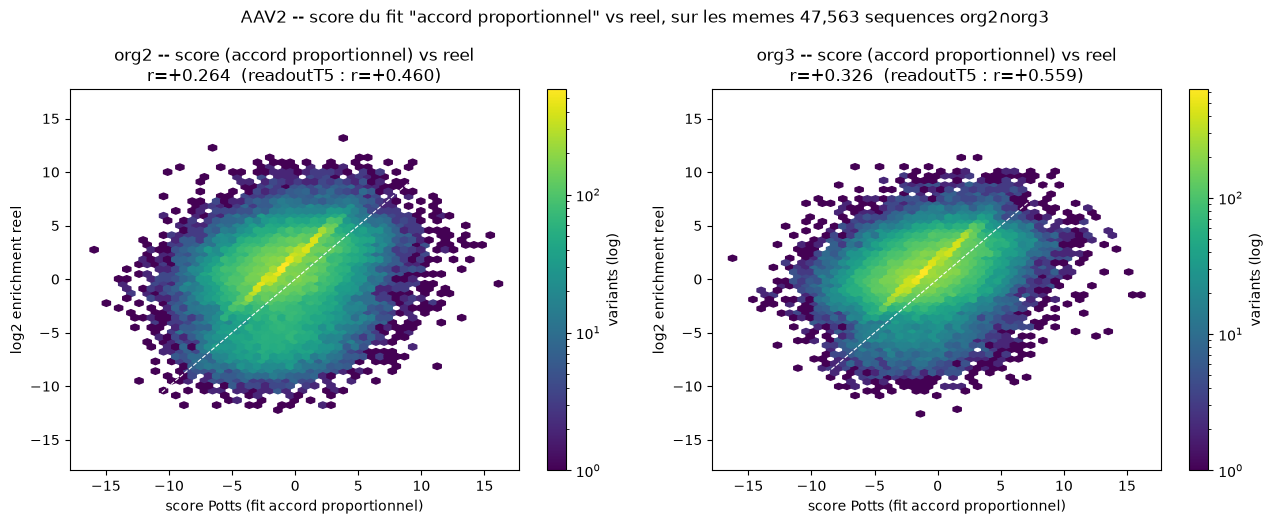

In [8]:
F_SEL_PROP_PATH = LIB / "aav2_F_sel_pool_potts_proportional_unreg.npy"
J_SEL_PROP_PATH = LIB / "aav2_J_sel_pool_potts_proportional_unreg.npy"
for p in (F_SEL_PROP_PATH, J_SEL_PROP_PATH):
    assert p.exists(), (f"{p.name} introuvable -- lancer AAV2_SEL_potts_proportional_agreement.ipynb "
                        f"d'abord (filtre |org2-org3|<=(org2+org3)/5)")

F_sel_prop = np.load(F_SEL_PROP_PATH)
J_sel_prop = np.load(J_SEL_PROP_PATH)
sel_score_prop = score_FJ(seq_matrix, F_sel_prop, J_sel_prop)

r_sel_prop = {i: pearson(y_sel[i], sel_score_prop) for i in (2, 3)}
for i in (2, 3):
    print(f"r(score accord-proportionnel, reel org{i}) = {r_sel_prop[i]:+.3f}   "
          f"(vs r(score readoutT5, reel org{i}) = {r_sel_gt[i]:+.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
for ax, i in zip(axes, (2, 3)):
    hb = ax.hexbin(sel_score_prop, y_sel[i], gridsize=50, bins="log", cmap="viridis", mincnt=1)
    lo, hi = min(sel_score_prop.min(), y_sel[i].min()), max(sel_score_prop.max(), y_sel[i].max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"org{i} -- score (accord proportionnel) vs reel\nr={r_sel_prop[i]:+.3f}  "
                 f"(readoutT5 : r={r_sel_gt[i]:+.3f})",
           xlabel="score Potts (fit accord proportionnel)", ylabel="log2 enrichment reel")
    fig.colorbar(hb, ax=ax, label="variants (log)")
fig.suptitle(f"AAV2 -- score du fit \"accord proportionnel\" vs reel, sur les memes {d0:,} sequences org2∩org3")
plt.tight_layout(); plt.show()

### 7. Recovery des meilleurs variants

Pour chaque cible (viab, sel org2, sel org3) : quelle fraction du vrai top-k% (classé par la mesure réelle) est retrouvée dans le top-k% classé par (a) le score GT déterministe, (b) le log enrichment simulé. Ligne pointillée = tirage au hasard.

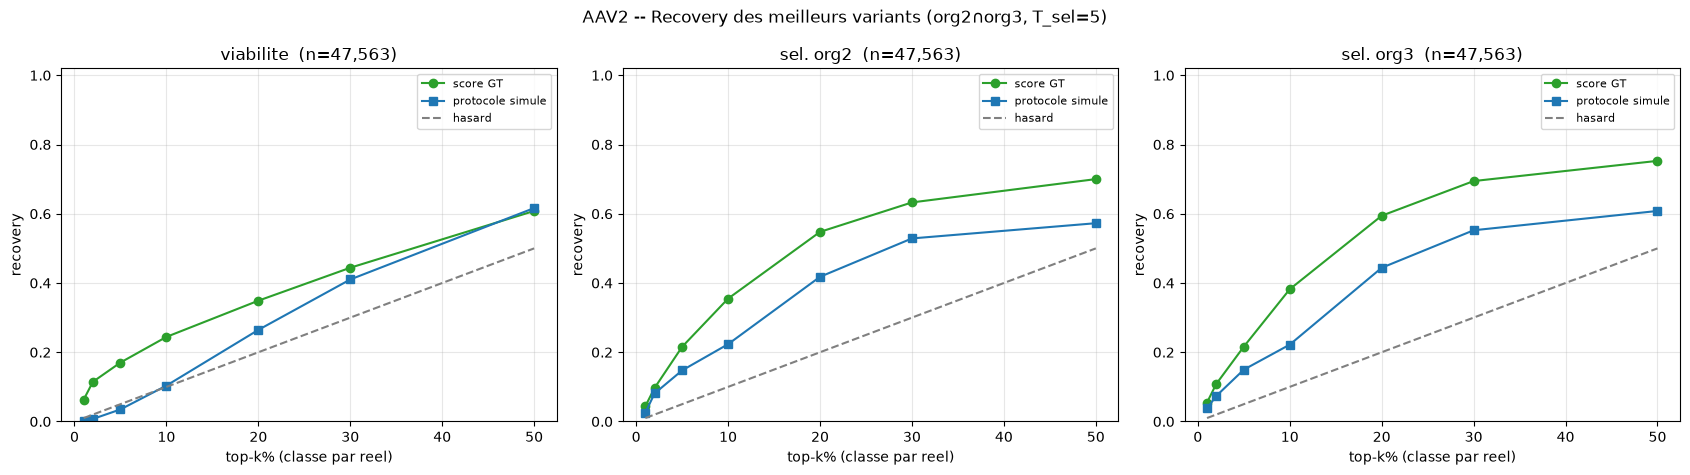

recovery_GT                     recovery_sim                    
cible    sel. org2 sel. org3 viabilite    sel. org2 sel. org3 viabilite
top_k%                                                                 
1            0.044     0.055     0.063        0.025     0.038     0.002
2            0.097     0.108     0.115        0.081     0.074     0.007
5            0.216     0.216     0.170        0.148     0.150     0.035
10           0.355     0.382     0.244        0.223     0.222     0.104
20           0.548     0.594     0.349        0.418     0.444     0.265
30           0.633     0.694     0.444        0.529     0.552     0.410
50           0.700     0.753     0.608        0.573     0.608     0.616

In [9]:
PCTS = [1, 2, 5, 10, 20, 30, 50]

def recovery_curve(y_real, ranker, mask=None):
    if mask is None:
        mask = np.ones_like(y_real, dtype=bool)
    yr, rk = y_real[mask], ranker[mask]
    ok = np.isfinite(yr) & np.isfinite(rk)
    yr, rk = yr[ok], rk[ok]
    return [precision_at_k(yr, rk, k_frac=p / 100) for p in PCTS], len(yr)

targets = [
    ("viabilite", y_viab,    viab_score_GT, sim_viab,           np.isfinite(y_viab)),
    ("sel. org2", y_sel[2],  sel_score_GT,  sims[0]["sim_sel"], None),
    ("sel. org3", y_sel[3],  sel_score_GT,  sims[0]["sim_sel"], None),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
rows = []
for ax, (name, y_real, gt, simlog, mask) in zip(axes, targets):
    rec_gt,  n = recovery_curve(y_real, gt, mask)
    rec_sim, _ = recovery_curve(y_real, simlog, mask)
    ax.plot(PCTS, rec_gt,  "o-", color="tab:green", label="score GT")
    ax.plot(PCTS, rec_sim, "s-", color="tab:blue",  label="protocole simule")
    ax.plot(PCTS, [p / 100 for p in PCTS], "--", color="grey", label="hasard")
    ax.set(title=f"{name}  (n={n:,})", xlabel="top-k% (classe par reel)",
           ylabel="recovery", ylim=(0, 1.02)); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    for p, g, s in zip(PCTS, rec_gt, rec_sim):
        rows.append({"cible": name, "top_k%": p, "recovery_GT": round(g, 3), "recovery_sim": round(s, 3)})
fig.suptitle("AAV2 -- Recovery des meilleurs variants (org2∩org3, T_sel=5)")
plt.tight_layout(); plt.show()
pd.DataFrame(rows).pivot(index="top_k%", columns="cible", values=["recovery_GT", "recovery_sim"])

### 8. Population à travers le pipeline simulé

In [10]:
p0 = sims[0]["p"]
lambdas_np = {
    "lambda0 (librairie = avg org2/org3)": np.asarray(p0.lambda0),
    "lambda0p (NGS plasmide simule)":      sims[0]["l0p"],
    "lambda2 (capsides)":                  np.asarray(p0.lambda2),
    "lambda2p (NGS virus simule)":         sims[0]["l2p"],
    "lambda3 (post-selectivite)":          np.asarray(p0.lambda3),
    "lambda3p (NGS organoide simule)":     sims[0]["l3p"],
}
summary = pd.DataFrame({
    "total": [a.sum() for a in lambdas_np.values()],
    "n_variants (>=1)": [int((a >= 1).sum()) for a in lambdas_np.values()],
    "fraction_d0": [float((a >= 1).mean()) for a in lambdas_np.values()],
}, index=list(lambdas_np))
display(summary)
display(number_of_seq_threshold(lambdas_np, thresholds=[1, 10, 100, 1000]))

,total,n_variants (>=1),fraction_d0
lambda0 (librairie = avg org2/org3),1.947751e+12,47563,1.000000
lambda0p (NGS plasmide simule),9.999664e+07,46398,0.975506
lambda2 (capsides),1.668666e+10,43718,0.919160
lambda2p (NGS virus simule),9.999789e+07,29161,0.613103
lambda3 (post-selectivite),1.996515e+10,43718,0.919160
lambda3p (NGS organoide simule),9.999824e+07,24520,0.515527


,1.0,10.0,100.0,1000.0
lambda,,,,
lambda0 (librairie = avg org2/org3),47563,47563,47563,47563
lambda0p (NGS plasmide simule),46398,44814,42188,20099
lambda2 (capsides),43718,43718,43718,43718
lambda2p (NGS virus simule),29161,29120,28264,17920
lambda3 (post-selectivite),43718,43718,43716,43478
lambda3p (NGS organoide simule),24520,24450,23560,13695


### 9. Notes

- Paramètres protocole (`mu`/`T`/`noise`/`D`) **non recalibrés pour AAV2** -- repris tels quels du point de fonctionnement établi sur AAV5 (`AAV5_SEL_fitting_protocol.ipynb`), comme demandé ("paramètres classiques, pas de sweep"). Piste ouverte, non faite ici : recherche `mu`/`T`/`noise`/`D` spécifique à AAV2, comme celle déjà identifiée comme manquante pour AAV5 (cf. `CLAUDE.md`, jamais faite non plus là-bas).
- Poids de sélectivité = fit mutualisé org2+org3 à `compte>=5` (`AAV2_SEL_potts_readout_depth.ipynb`, décision 2026-09-16) -- pas re-fittés sur ce sous-échantillon précis org2∩org3 (critère `>0` plutot que `>=5`). Le plafond réel sur ce sous-ensemble est `r(org2, org3)` affiché en section 6.
- Poids de viabilité = `aav2_F_viab_potts_sorted_cv.npy` (lignée organoïde/haute-diversité, `AAV2_viab_sorting.ipynb`) -- **PAS** la GT canonique par défaut de `AAV2_potts_regression.ipynb` §12c (`aav2_F_viab_potts_plasmid50_vectorpos_cv.npy`, lignée basse-diversité `aav2.csv`) : choisi ici pour rester dans la même lignée de données que les poids de sélectivité (mêmes séquences organoïde, même CSV source) -- même logique que le choix `aav5_F_viab_potts_sorted_unreg.npy` du notebook AAV5 source (AAV5 n'a qu'une seule lignée viab, donc ce choix n'y était pas ambigu).
- `plasmid_count = avg(compte_organoide_2_adn, compte_organoide_3_adn)` sert de librairie initiale à la place du vrai `compte_plasmide` -- un choix délibéré de ce run (repris identique du port AAV5), pas une approximation du plasmide réel.